# SVM Diabetes Risk Classification — Grid Search

Notebook ini melatih model **Support Vector Machine (SVM)** untuk memprediksi `diabetes_risk` menggunakan:

- train-test split terstratifikasi,
- preprocessing numerik dan kategorik,
- `GridSearchCV`,
- evaluasi menggunakan Accuracy dan Macro F1,
- penyimpanan seluruh pipeline sebagai file `.joblib`.

Kolom `patient_id` tidak digunakan sebagai fitur prediktor.

In [1]:
# Jika library belum tersedia, jalankan:
# !pip install pandas numpy scikit-learn joblib matplotlib

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42


## 1. Load Dataset

In [2]:
DATA_PATH = Path("diabetes_risk.csv")

# Jika notebook dijalankan dari folder lain, ubah path di atas sesuai lokasi dataset.
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (15000, 19)


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [3]:
df.info()

print("\nDistribusi target:")
display(
    df["diabetes_risk"]
    .value_counts()
    .rename_axis("Class")
    .to_frame("Count")
    .assign(Percentage=lambda x: x["Count"] / x["Count"].sum() * 100)
)


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

,Count,Percentage
Class,,
Low,9000,60.0
Moderate,3750,25.0
High,2250,15.0


## 2. Menentukan Fitur dan Target

In [4]:
TARGET = "diabetes_risk"
DROP_COLUMNS = ["patient_id"]

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Target:", TARGET)
print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Target: diabetes_risk

Numeric features:
['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']

Categorical features:
['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']


## 3. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nDistribusi target train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribusi target test:")
print(y_test.value_counts(normalize=True).sort_index())


Train: (12000, 17)
Test : (3000, 17)

Distribusi target train:
diabetes_risk
High        0.15
Low         0.60
Moderate    0.25
Name: proportion, dtype: float64

Distribusi target test:
diabetes_risk
High        0.15
Low         0.60
Moderate    0.25
Name: proportion, dtype: float64


## 4. Preprocessing

Preprocessing dimasukkan ke dalam `Pipeline` agar preprocessing pada data baru di Streamlit selalu sama dengan preprocessing saat training.

- Numerik: imputasi median + `StandardScaler`
- Kategorik: imputasi modus + `OneHotEncoder(handle_unknown="ignore")`


In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC())
])

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

## 5. Grid Search SVM

Karena target tidak seimbang, pemilihan model menggunakan **Macro F1** sehingga setiap kelas memperoleh bobot evaluasi yang sama.

Parameter yang diuji:

- `C`: 0.1, 1, 10
- kernel: linear dan RBF
- `gamma`: khusus RBF
- `class_weight`: tanpa pembobotan dan `balanced`


In [ ]:
param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10],
        "svm__class_weight": [None, "balanced"]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1],
        "svm__class_weight": [None, "balanced"]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=False
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END svm__C=0.1, svm__class_weight=None, svm__kernel=linear; total time=   2.0s
[CV] END svm__C=0.1, svm__class_weight=None, svm__kernel=linear; total time=   2.0s
[CV] END svm__C=0.1, svm__class_weight=None, svm__kernel=linear; total time=   2.1s
[CV] END svm__C=0.1, svm__class_weight=balanced, svm__kernel=linear; total time=   2.5s
[CV] END svm__C=0.1, svm__class_weight=balanced, svm__kernel=linear; total time=   2.5s
[CV] END svm__C=1, svm__class_weight=None, svm__kernel=linear; total time=   2.7s
[CV] END svm__C=0.1, svm__class_weight=balanced, svm__kernel=linear; total time=   2.6s
[CV] END svm__C=1, svm__class_weight=None, svm__kernel=linear; total time=   2.7s
[CV] END svm__C=1, svm__class_weight=None, svm__kernel=linear; total time=   2.9s
[CV] END svm__C=1, svm__class_weight=balanced, svm__kernel=linear; total time=   3.1s
[CV] END svm__C=1, svm__class_weight=balanced, svm__kernel=linear; total time=   2.7s
[CV] 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svm__C': [0.1, 1, ...], 'svm__class_weight': [None, 'balanced'], 'svm__kernel': ['linear']}, {'svm__C': [0.1, 1, ...], 'svm__class_weight': [None, 'balanced'], 'svm__gamma': ['scale', 0.01, ...], 'svm__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specific

## 6. Model Terbaik

In [8]:
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print(f"\nBest CV Macro F1: {grid_search.best_score_:.4f}")


Best parameters:
{'svm__C': 0.1, 'svm__class_weight': None, 'svm__kernel': 'linear'}

Best CV Macro F1: 0.7425


In [9]:
# Ringkasan hasil seluruh kombinasi Grid Search
cv_results = pd.DataFrame(grid_search.cv_results_)

result_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_svm__kernel",
    "param_svm__C",
    "param_svm__gamma",
    "param_svm__class_weight"
]

display(
    cv_results[result_columns]
    .sort_values("rank_test_score")
    .head(15)
)


,rank_test_score,mean_test_score,std_test_score,param_svm__kernel,param_svm__C,param_svm__gamma,param_svm__class_weight
0,1,0.742489,0.007401,linear,0.1,NaN,NaN
2,2,0.741647,0.008209,linear,1.0,NaN,NaN
16,3,0.741093,0.006182,rbf,1.0,0.01,balanced
4,4,0.741033,0.007706,linear,10.0,NaN,NaN
13,5,0.740366,0.006527,rbf,1.0,0.01,NaN
19,6,0.738714,0.009491,rbf,10.0,0.01,NaN
1,7,0.738436,0.005297,linear,0.1,NaN,balanced
9,8,0.737898,0.009641,rbf,0.1,scale,balanced
12,9,0.737196,0.006193,rbf,1.0,scale,NaN
5,10,0.736973,0.005410,linear,10.0,NaN,balanced


## 7. Evaluasi pada Test Set

In [10]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Test Accuracy    : {accuracy:.4f}")
print(f"Test Macro F1    : {macro_f1:.4f}")
print(f"Test Weighted F1 : {weighted_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy    : 0.7940
Test Macro F1    : 0.7447
Test Weighted F1 : 0.7913

Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.70      0.77       450
         Low       0.86      0.91      0.88      1800
    Moderate       0.60      0.57      0.58       750

    accuracy                           0.79      3000
   macro avg       0.76      0.73      0.74      3000
weighted avg       0.79      0.79      0.79      3000



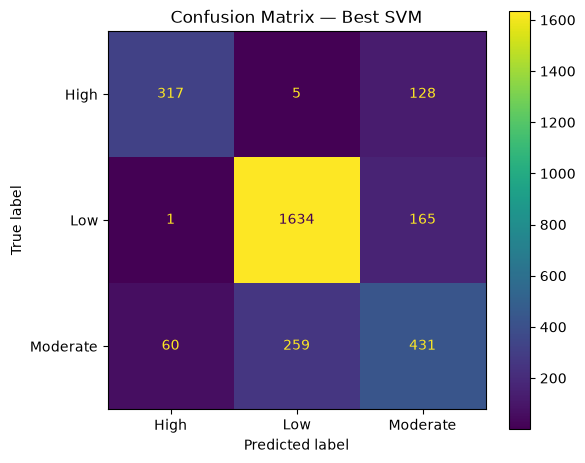

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=best_model.classes_,
    ax=ax
)

ax.set_title("Confusion Matrix — Best SVM")
plt.tight_layout()
plt.show()


## 8. Simpan Model Terbaik

In [12]:
MODEL_PATH = Path("svm_diabetes_best_model.joblib")
METADATA_PATH = Path("svm_diabetes_metadata.json")

joblib.dump(best_model, MODEL_PATH)

metadata = {
    "target": TARGET,
    "excluded_columns": DROP_COLUMNS,
    "input_features": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "classes": best_model.classes_.tolist(),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "grid_scoring": "f1_macro",
    "cv": 3,
    "best_params": grid_search.best_params_,
    "best_cv_macro_f1": float(grid_search.best_score_),
    "test_accuracy": float(accuracy),
    "test_macro_f1": float(macro_f1),
    "test_weighted_f1": float(weighted_f1)
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Model saved to   :", MODEL_PATH.resolve())
print("Metadata saved to:", METADATA_PATH.resolve())


Model saved to   : /Users/mac/Documents/Python/PKL BAPPEDA/laporan/streamlit/svm_diabetes_best_model.joblib
Metadata saved to: /Users/mac/Documents/Python/PKL BAPPEDA/laporan/streamlit/svm_diabetes_metadata.json


## 9. Load Model untuk Prediksi

Model yang disimpan merupakan **seluruh pipeline**, sehingga input tidak perlu di-scaling atau di-one-hot encode secara manual.

In [13]:
loaded_model = joblib.load("svm_diabetes_best_model.joblib")

sample = X_test.iloc[[0]].copy()

display(sample)

prediction = loaded_model.predict(sample)[0]

print("Prediction:", prediction)
print("Actual    :", y_test.loc[sample.index[0]])


,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket
6245,45,Male,Kolkata,23.1,No,Active,Non-Vegetarian,Never,Never,8.0,7,172,6.8,130,84,105.9,Low


Prediction: Low
Actual    : Low


## 10. Contoh Integrasi dengan Streamlit

Pada aplikasi Streamlit, susun input sebagai `DataFrame` dengan **nama kolom yang sama** dengan data training, lalu panggil `model.predict()`.

```python
import joblib
import pandas as pd
import streamlit as st

@st.cache_resource
def load_model():
    return joblib.load("svm_diabetes_best_model.joblib")

model = load_model()

# input_data harus memiliki kolom yang sama dengan fitur saat training
prediction = model.predict(input_data)[0]

st.success(f"Prediksi risiko diabetes: {prediction}")
```
